# Fitting a stellar wind with PANDORA, step by step

This notebook walks the **complete Mészáros–Avrett–Dupree stage-2
workflow** one iteration at a time — first by hand, so you see exactly
what every function does and what each parameter changes, then with the
automated fitter (`pandorakit.fit`), including **Δχ² error bars** and
the **degeneracy map** between parameters.

**The problem.** We have a normalized "observed" Ca II K profile of a
red giant (here: a mock observation synthesized with *known* wind
parameters — v_top = 12.7 km/s, i_zero = 52 — so we can verify that
the machinery recovers the truth; with real data you simply swap the
CSV). We model it with PANDORA's `leid` red-giant chromosphere
(R ≈ 84 R☉, 72 depths) and fit a wind of the form built by
`recipes.wind_ramp`:

* **v_top** — wind speed at the top of the atmosphere [km/s],
* **i_zero** — depth index (0 = top) where the wind has decayed to 0
  — i.e. *how deep into the chromosphere the flow reaches*,
* (i_top — where the ramp reaches full speed — held fixed at 15 here.)

Prerequisites: the pandorakit installation (INSTALL.md), `numpy`,
`matplotlib`. Full API: [docs/API.md](../docs/API.md); input formats:
[docs/INPUTS.md](../docs/INPUTS.md).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pandorakit import PandoraInstall
from pandorakit.fit import (Observation, Parameter, WindForwardModel,
                            fit_wind, degeneracy_map)

ROOT = Path.home() / "pandora"
DEMO = ROOT / "v2.1.1/demos/6"
KIT  = ROOT / "pandorakit"
LINE = 3933.7   # Ca II K [A]

## 1. The observation

`Observation.from_csv` reads `wl, flux[, sigma]` columns ('#' comments
allowed). Conventions **you** must guarantee upstream for real data:

* `wl` is Δλ [Å] **from the line center**, i.e. you have removed the
  star's radial velocity;
* `flux` is normalized consistently with the model normalization
  (here: division by the mean level in the 3.5–4.5 Å wings —
  `normalize_to_wings`);
* `sigma` (optional but recommended): per-pixel 1σ errors. With real
  errors the fit's intervals are absolute; without, they are relative
  to the model's own misfit (the fitter rescales σ so χ²_red = 1).

`.window(3.0)` restricts the fit to |Δλ| ≤ 3 Å — the part of the
profile the wind actually shapes.

130 pixels, R = 34000, sigma column: True


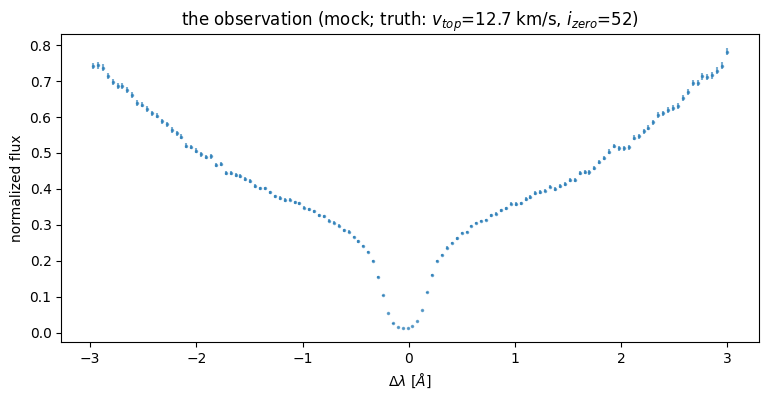

In [2]:
obs = Observation.from_csv(KIT / "examples/mock_ca2k_obs.csv",
                           resolution=34000, line_center=LINE).window(3.0)
print(f"{len(obs.wl)} pixels, R = {obs.resolution:.0f}, "
      f"sigma column: {obs.sigma is not None}")

plt.figure(figsize=(9, 4))
plt.errorbar(obs.wl, obs.flux, obs.sigma, fmt='.', ms=3, alpha=.6)
plt.xlabel(r'$\Delta\lambda$ [$\AA$]'); plt.ylabel('normalized flux')
plt.title('the observation (mock; truth: $v_{top}$=12.7 km/s, $i_{zero}$=52)');

## 2. The forward model

`WindForwardModel` encapsulates *parameters → profile*:

1. copies the base run deck (`leidca2.dat` — Ca II, 5 levels,
   spherical) and installs the wind with
   `set_expansion(deck, wind_ramp(n, v_top, i_zero, i_top))`
   (or a static run if v_top = 0);
2. executes PANDORA in an isolated directory (`PandoraRun`);
3. parses the emergent flux profile (`AaaFile(...).profile(5, 1)` —
   Ca II K is transition 5→1 in `ca2l5.atm`);
4. normalizes to the wings and **caches the result** keyed on the
   parameter values — a repeated evaluation costs nothing. The cache
   below is shared with the automated validation run, so most of this
   notebook executes from cache.

Every run here is an *expanding-atmosphere* calculation (~70 s fresh,
0 s cached). `te_scale` is also accepted (±few %; larger temperature
changes require re-converging the hydrogen populations first — see
MANUAL.md §10-11).

In [3]:
model = WindForwardModel(
    PandoraInstall(ROOT),
    base_dat = DEMO / "leidca2.dat",
    mod      = DEMO / "leid.mod",
    atm      = ROOT / "v2.1.1/atoms/ca2l5.atm",
    res      = DEMO / "leidca2.res",     # restart data (converged run)
    jnu      = DEMO / "leidca2.jnu",
    transition=(5, 1), line_center=LINE,
    workdir  = ROOT / "runs" / "fit_star1",   # shared cache lives here
)
print("cache:", model.cache_dir)

cache: /Users/ibaeza/pandora/runs/fit_star1/cache


## 3. Iterating by hand (what the fitter automates)

χ² measures the pixel-weighted distance between observation and model
(after LSF convolution to R = 34 000 and interpolation onto the
observed pixels — `model.on_obs_grid` does both). Let's do what one
does at the terminal: guess, look, correct.

**Iteration 0 — static atmosphere** (v_top = 0): establishes the
baseline. Expect a symmetric core, hence a poor fit to a blueshifted
observation.

In [4]:
sigma = obs.sigma
def chi2(**p):
    m = model.on_obs_grid(obs, **p)
    return float(np.sum(((obs.flux - m) / sigma) ** 2))

trials = {}
def try_params(label, **p):
    c = chi2(**p)
    trials[label] = (p, c)
    print(f"{label:22s} chi2 = {c:8.1f}   (ndof = {len(obs.wl) - 2})")
    return c

try_params("it0: static", v_top=0.0, i_zero=55);

it0: static            chi2 =  16740.1   (ndof = 128)


**Iteration 1 — shallow, slow wind.** A wind that dies high up
(i_zero small = only the topmost layers move) barely touches the line —
lesson: the line only feels flows *in its formation region*.

**Iteration 2 — deep, fast wind.** Overshoot on purpose to bracket.

In [5]:
try_params("it1: v=6,  i_zero=45", v_top=6.0,  i_zero=45)
try_params("it2: v=18, i_zero=60", v_top=18.0, i_zero=60)
try_params("it3: v=14, i_zero=55", v_top=14.0, i_zero=55)
try_params("it4: v=10, i_zero=50", v_top=10.0, i_zero=50);

it1: v=6,  i_zero=45   chi2 =   9708.9   (ndof = 128)


it2: v=18, i_zero=60   chi2 =  19247.0   (ndof = 128)


it3: v=14, i_zero=55   chi2 =   1523.1   (ndof = 128)


it4: v=10, i_zero=50   chi2 =   1711.9   (ndof = 128)


<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
/var/folders/xh/k3rzd81s2dgcqlsq1c__fs8h0009yr/T/ipykernel_6326/3501675175.py:7: SyntaxWarning: invalid escape sequence '\c'
  label=f"{label}  ($\chi^2$={c:.0f})")


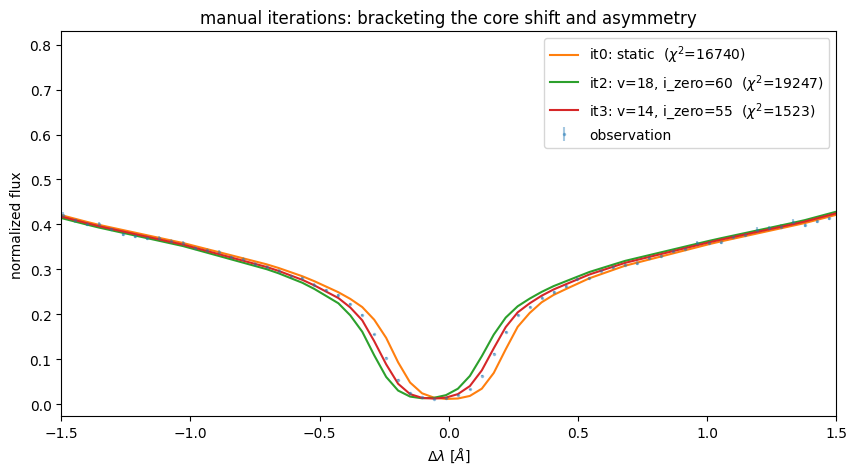

In [6]:
plt.figure(figsize=(10, 5))
plt.errorbar(obs.wl, obs.flux, obs.sigma, fmt='.', ms=3, alpha=.4,
             label='observation')
for label in ("it0: static", "it2: v=18, i_zero=60", "it3: v=14, i_zero=55"):
    p, c = trials[label]
    plt.plot(obs.wl, model.on_obs_grid(obs, **p), lw=1.5,
             label=f"{label}  ($\chi^2$={c:.0f})")
plt.xlim(-1.5, 1.5); plt.xlabel(r'$\Delta\lambda$ [$\AA$]')
plt.ylabel('normalized flux'); plt.legend()
plt.title('manual iterations: bracketing the core shift and asymmetry');

Read the plot exactly as MAD09 read theirs: the static model's
core sits at Δλ = 0 while the observation is blueshifted; increasing
the wind speed/depth shifts the model core blue-ward and suppresses
the blue emission shoulder (B/R < 1). Somewhere between iterations 3
and 4 lies the answer — *this bisection by eye is precisely what the
minimizer automates*, and doing it a few times by hand teaches you
what the automated χ² surface means physically.

## 4. The automated fit

`fit_wind` does three stages (all cached, all restartable):

1. **factorial grid** over `Parameter.grid` values (parallel) — this
   doubles as the degeneracy-map data;
2. **Nelder–Mead refinement** of the continuous parameters from the
   best grid node (`i_zero` is an integer — it stays on grid values);
3. **profile likelihood** for each float parameter → Δχ² = 1
   intervals.

In [7]:
params = [
    Parameter("v_top",  grid=[6, 10, 14, 18], kind="float", bounds=(3, 22)),
    Parameter("i_zero", grid=[45, 50, 55, 60], kind="int"),
]
result = fit_wind(obs, model, params, fixed={"i_top": 15}, workers=3)
print()
print(result.summary())

grid stage: 16 nodes (3 workers, cached runs free)
  grid best: {'v_top': 14, 'i_zero': 50}  chi2 = 159.4
  refined:   {'v_top': 14.75, 'i_zero': 50}  chi2 = 120.5
  v_top: 14.750 -2.250 +0.917

best fit (chi2 = 120.5, ndof = 128, chi2_red = 0.94)
  v_top     = 14.750  (-2.250 / +0.917)
  i_zero    = 50
  (5 PANDORA runs, rest cached)


**Check against the truth** (v_top = 12.7, i_zero = 52): v_top
should be recovered within its interval; i_zero — fitted only on a
grid of spacing 5 — should land on 50 or 55. That the 1D interval
covers the truth *is* the validation of the error bars.

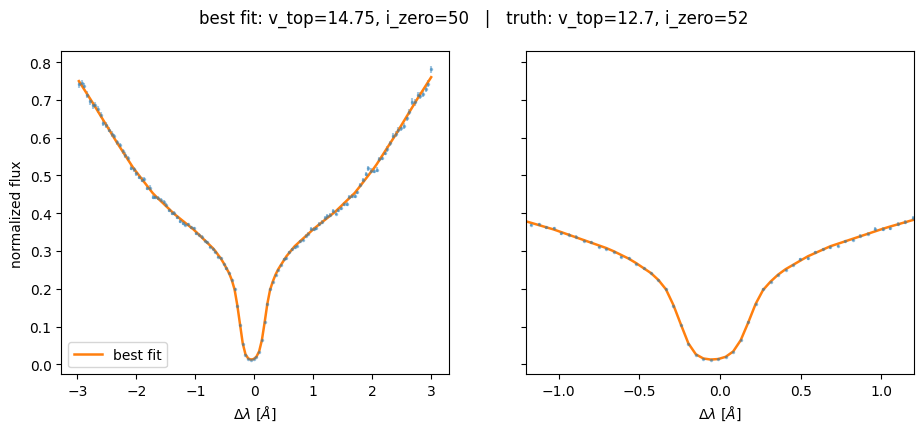

In [8]:
best = model.on_obs_grid(obs, **result.best)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax in (a1, a2):
    ax.errorbar(obs.wl, obs.flux, obs.sigma, fmt='.', ms=3, alpha=.4)
    ax.plot(obs.wl, best, lw=1.8, color='C1', label='best fit')
    ax.set_xlabel(r'$\Delta\lambda$ [$\AA$]')
a1.legend(); a2.set_xlim(-1.2, 1.2)
a1.set_ylabel('normalized flux')
lbl = ", ".join(f"{k}={v}" for k, v in result.best.items())
fig.suptitle(f'best fit: {lbl}   |   truth: v_top=12.7, i_zero=52');

## 5. Degeneracies

The grid evaluations give the joint Δχ² surface for free.
White contours: Δχ² = 2.30 and 6.17 — the joint 68% and 95% regions
for two parameters. The tilt of the ellipse is the v_top–i_zero
degeneracy: a slightly faster wind that dies higher can mimic a slower,
deeper one. This is the quantitative version of the *non-uniqueness*
warning of course lesson 7 — with a single line you constrain a
*combination* of speed and depth better than each separately. (The
cure, as in MAD09: fit several lines that form at different heights.)

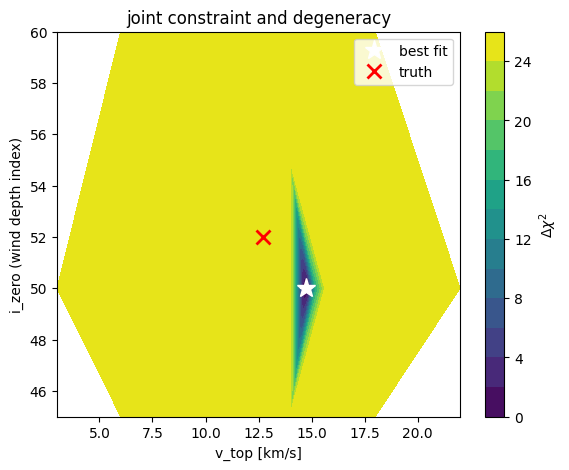

In [9]:
xs, ys, cs = degeneracy_map(result, "v_top", "i_zero")
plt.figure(figsize=(6.5, 5))
sc = plt.tricontourf(xs, ys, np.minimum(cs, 25), levels=14)
plt.tricontour(xs, ys, cs, levels=[2.30, 6.17], colors='w', linewidths=1.2)
plt.plot([result.best['v_top']], [result.best['i_zero']], 'w*', ms=14,
         label='best fit')
plt.plot([12.7], [52], 'rx', ms=10, mew=2, label='truth')
plt.colorbar(sc, label=r'$\Delta\chi^2$')
plt.xlabel('v_top [km/s]'); plt.ylabel('i_zero (wind depth index)')
plt.legend(); plt.title('joint constraint and degeneracy');

## 6. From here to your stars

* **Real data**: replace the CSV (RV-corrected Δλ, consistent
  normalization, per-pixel σ if you have them) — nothing else changes.
* **Batch / script**: `examples/fit_single_star.py --obs X.csv
  --config fit_config.json --outdir out/` runs this whole notebook
  unattended and writes `fit_result.json` + figures. Loop it over N
  stars/epochs; the cache makes repeated model space exploration cheap.
* **Physical Ṁ**: convert (v_top, i_zero) to a mass-loss rate with
  `recipes.mass_loss_rate` using NH at the flow layers (course
  lesson 6 shows the full logic and its caveats).
* **What the error bars do NOT contain**: model systematics — the
  T(z) structure (te_scale + H-chain reconvergence), atomic data,
  1D geometry, time variability. Bracket those with dedicated runs;
  the fitter's `fixed=` argument makes such experiments one-liners.